# MLP: Bus Delay Multi-Class Classification

## Data Setup
- **Stops**: Urban core only (downtown Seattle + Capitol Hill + SLU) — lat 47.590–47.630, lon -122.355–-122.310
- **Weather**: Dry (WMO 0,1,2,3) vs Rain (WMO 61,63) — drizzle (51,53,55) and snow (71,73) excluded
- **Balance**: Dry undersampled to match rain count (743 each → 1,486 total)

## Target: 5-class delay label
| Class | Label | Condition |
|---|---|---|
| 0 | On time | delay ≤ 0 min |
| 1 | < 1 min | 0 < delay ≤ 1 min |
| 2 | 1–3 min | 1 < delay ≤ 3 min |
| 3 | 3–5 min | 3 < delay ≤ 5 min |
| 4 | > 5 min | delay > 5 min |

## Features
- `route_enc`, `hour_of_day`, `day_of_week`, `is_weekend`, `is_peak_hour`, `is_raining`, `precipitation_mm`
- **Interactions** (professor's suggestion): `peak × rain`, `hour × rain`, `route × rain`
- Note: features are **StandardScaler normalized** before training

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Load data ──────────────────────────────────────────────────────────────
stops = pd.read_csv('../data/stops.csv')
df    = pd.read_csv('../data/processed/dataset.csv')

# Urban core bounding box
urban = stops[
    (stops['lat'] >= 47.590) & (stops['lat'] <= 47.630) &
    (stops['lon'] >= -122.355) & (stops['lon'] <= -122.310)
]
df = df[df['stop_id'].isin(urban['stop_id'].tolist())]

# ── 2. Weather filter & balance ───────────────────────────────────────────────
rain_df = df[df['weather_code'].isin([61, 63])]
dry_df  = df[df['weather_code'].isin([0, 1, 2, 3])].sample(n=len(rain_df), random_state=42)
df = pd.concat([rain_df, dry_df]).reset_index(drop=True)

print(f'Dataset: {len(df)} rows  (Rain: {len(rain_df)}, Dry: {len(dry_df)})')

# ── 3. Multi-class label ──────────────────────────────────────────────────────
CLASS_NAMES = ['On time', '< 1 min', '1-3 min', '3-5 min', '> 5 min']

def delay_class(d):
    if d <= 0:   return 0  # On time
    elif d <= 1: return 1  # < 1 min
    elif d <= 3: return 2  # 1-3 min
    elif d <= 5: return 3  # 3-5 min
    else:        return 4  # > 5 min

df['delay_class'] = df['delay_min'].apply(delay_class)
print('\nClass distribution:')
print(df['delay_class'].map(dict(enumerate(CLASS_NAMES))).value_counts().reindex(CLASS_NAMES))

Dataset: 1486 rows  (Rain: 743, Dry: 743)

Class distribution:
delay_class
On time    572
< 1 min    169
1-3 min    322
3-5 min    181
> 5 min    242
Name: count, dtype: int64


In [2]:
# ── 4. Feature engineering ────────────────────────────────────────────────────
# Redefine is_raining: only real rain (no drizzle)
df['is_raining'] = df['weather_code'].isin([61, 63]).astype(int)

# Encode route_id
le = LabelEncoder()
df['route_enc'] = le.fit_transform(df['route_id'].astype(str))

# Interaction features (professor's suggestion)
df['peak_x_rain']  = df['is_peak_hour'] * df['is_raining']
df['hour_x_rain']  = df['hour_of_day']  * df['is_raining']
df['route_x_rain'] = df['route_enc']    * df['is_raining']

FEATURES = [
    'route_enc', 'hour_of_day', 'day_of_week', 'is_weekend',
    'is_peak_hour', 'is_raining', 'precipitation_mm',
    'peak_x_rain', 'hour_x_rain', 'route_x_rain'
]

X = df[FEATURES]
y = df['delay_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# MLP requires feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 1188, Test: 298


In [3]:
# ── 5. MLP model ──────────────────────────────────────────────────────────────
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

=== Classification Report ===
              precision    recall  f1-score   support

     On time       0.39      1.00      0.56       115
     < 1 min       0.00      0.00      0.00        34
     1-3 min       0.00      0.00      0.00        65
     3-5 min       0.00      0.00      0.00        36
     > 5 min       0.00      0.00      0.00        48

    accuracy                           0.39       298
   macro avg       0.08      0.20      0.11       298
weighted avg       0.15      0.39      0.21       298



/Users/jennykim/Documents/ML6140/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jennykim/Documents/ML6140/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jennykim/Documents/ML6140/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

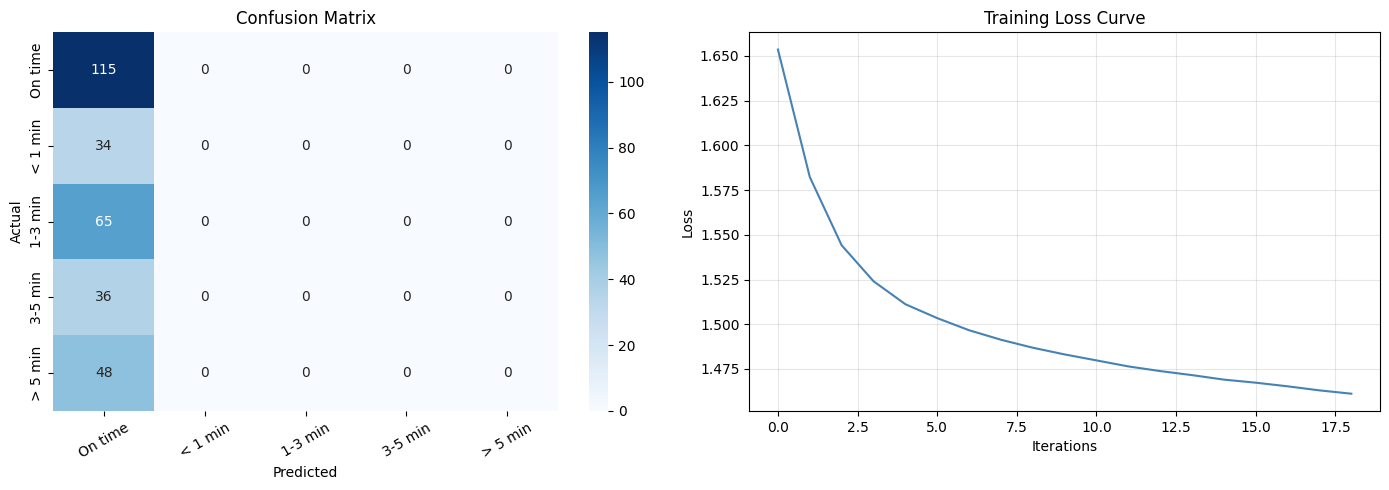

In [4]:
# ── 6. Confusion matrix & training loss ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(model.loss_curve_, color='steelblue')
axes[1].set_title('Training Loss Curve')
axes[1].set_xlabel('Iterations')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# ── 7. Cross-validation ───────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

cv_model = make_pipeline(StandardScaler(), MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu',
    max_iter=500, random_state=42,
    early_stopping=True, validation_fraction=0.1
))
cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold: {cv_scores.round(4)}')

5-Fold CV Accuracy: 0.3769 ± 0.0144
Per-fold: [0.3523 0.3704 0.3939 0.3838 0.3838]


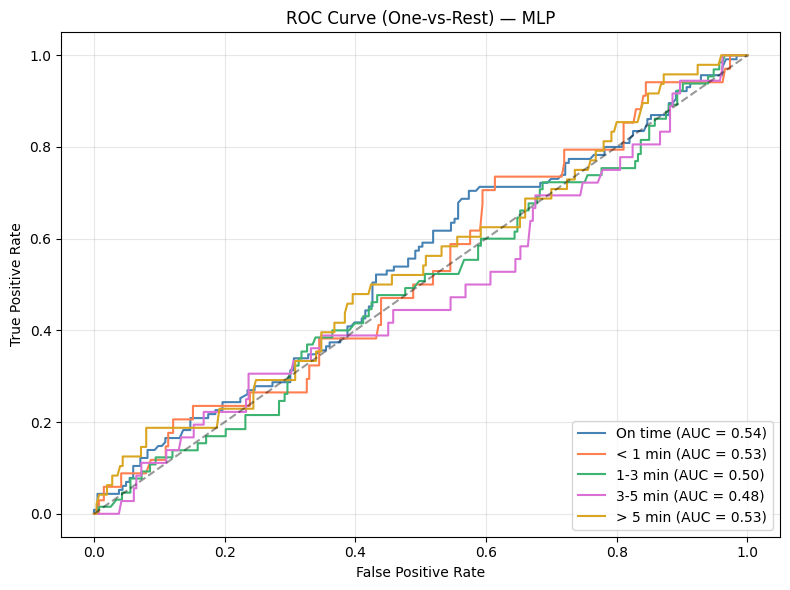

In [6]:
# ── 8. ROC curve (one-vs-rest) ────────────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin  = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
y_proba_all = model.predict_proba(X_test_sc)

colors = ['steelblue', 'coral', 'mediumseagreen', 'orchid', 'goldenrod']
plt.figure(figsize=(8, 6))
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_all[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) — MLP')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Additional Test: 3-Class Classification

AUC scores from the 5-class model ranged from 0.48–0.54, essentially random. Merging into 3 classes to reduce label noise.

**Merging into 3 classes:**
| Class | Label | Condition |
|---|---|---|
| 0 | On time | delay ≤ 0 min |
| 1 | Slightly late | 0 < delay ≤ 3 min |
| 2 | Late | delay > 3 min |

In [ ]:
# ── 3-class label ─────────────────────────────────────────────────────────────
CLASS_NAMES_3 = ['On time', 'Slightly late', 'Late']

def delay_class_3(d):
    if d <= 0:   return 0
    elif d <= 3: return 1
    else:        return 2

df['delay_class_3'] = df['delay_min'].apply(delay_class_3)
print('3-class distribution:')
print(df['delay_class_3'].map(dict(enumerate(CLASS_NAMES_3))).value_counts().reindex(CLASS_NAMES_3))

X3 = df[FEATURES]
y3 = df['delay_class_3']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

model3 = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation='relu',
    max_iter=500, random_state=42,
    early_stopping=True, validation_fraction=0.1
)
model3.fit(X3_train_sc, y3_train)
y3_pred = model3.predict(X3_test_sc)

print('\n=== Classification Report (3-class) ===')
print(classification_report(y3_test, y3_pred, target_names=CLASS_NAMES_3))

In [ ]:
# ── Confusion matrix & ROC (3-class) ─────────────────────────────────────────
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm3 = confusion_matrix(y3_test, y3_pred)
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES_3, yticklabels=CLASS_NAMES_3)
axes[0].set_title('Confusion Matrix (3-class)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

y3_test_bin  = label_binarize(y3_test, classes=[0, 1, 2])
y3_proba_all = model3.predict_proba(X3_test_sc)

colors = ['steelblue', 'coral', 'mediumseagreen']
for i, (name, color) in enumerate(zip(CLASS_NAMES_3, colors)):
    fpr, tpr, _ = roc_curve(y3_test_bin[:, i], y3_proba_all[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (One-vs-Rest) — 3-class')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()